<a href="https://colab.research.google.com/github/tejasmunda-boop/Mac/blob/main/project_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Loading Pet Dataset (Cats & Dogs)...
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


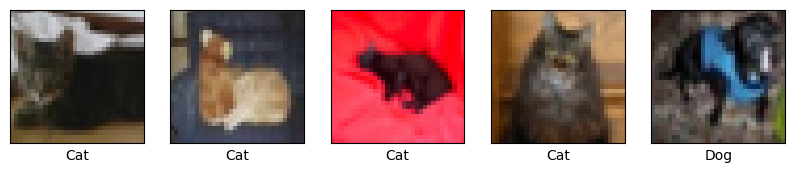

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Starting Model Training...
Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 41ms/step - accuracy: 0.6083 - loss: 0.6573 - val_accuracy: 0.6410 - val_loss: 0.6214
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 41ms/step - accuracy: 0.6857 - loss: 0.5899 - val_accuracy: 0.7140 - val_loss: 0.5601
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 40ms/step - accuracy: 0.7181 - loss: 0.5467 - val_accuracy: 0.7270 - val_loss: 0.5319
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 40ms/step - accuracy: 0.7472 - loss: 0.5101 - val_accuracy: 0.7370 - val_loss: 0.5162
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 39ms/step - accuracy: 0.7613 - loss: 0.4856 - val_accuracy: 0.7350 - val_loss: 0.5206


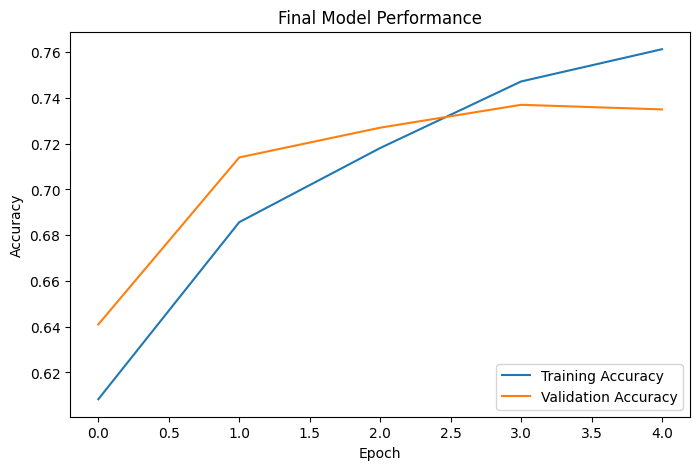


Final Validation Accuracy: 73.50%


In [1]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np

# --- 1. LOAD DATASET (Fixed for Scalar Index Error) ---
print("Loading Pet Dataset (Cats & Dogs)...")
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()

# FIX: Flatten labels to 1D to avoid TypeError: only integer scalar arrays...
train_labels = train_labels.flatten()
test_labels = test_labels.flatten()

# CIFAR-10 classes: 3 is Cat, 5 is Dog. Filter for just these two.
train_mask = np.isin(train_labels, [3, 5])
test_mask = np.isin(test_labels, [3, 5])

X_train, y_train = train_images[train_mask], train_labels[train_mask]
X_test, y_test = test_images[test_mask], test_labels[test_mask]

# Map labels: Cat (3) -> 0, Dog (5) -> 1
y_train = np.where(y_train == 3, 0, 1)
y_test = np.where(y_test == 3, 0, 1)

# Normalize pixel values to be between 0 and 1
X_train, X_test = X_train / 255.0, X_test / 255.0

# --- 2. EXPLORATORY DATA ANALYSIS (EDA) ---
class_names = ['Cat', 'Dog']
plt.figure(figsize=(10,4))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(X_train[i])
    plt.xlabel(class_names[y_train[i]])
plt.show()

# --- 3. MODEL ARCHITECTURE (CNN) ---
# This explains how the computer "sees" the pet faces through layers
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(2, activation='softmax')
])

model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              metrics=['accuracy'])

# --- 4. EXECUTION ---
print("\nStarting Model Training...")
# Using fewer epochs for a quick run in VS Code; increase for better accuracy
history = model.fit(X_train, y_train, epochs=5,
                    validation_data=(X_test, y_test))

# --- 5. EVALUATION ---
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label = 'Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.title('Final Model Performance')
plt.show()

print(f"\nFinal Validation Accuracy: {history.history['val_accuracy'][-1]*100:.2f}%")
